# 03. Hyperparameter Tuning — GridSearchCV & RandomizedSearchCV

This notebook optimises hyperparameters for **4 models** using scikit-learn's `GridSearchCV` (for smaller search spaces) and `RandomizedSearchCV` (for XGBoost's larger search space).

| Model | Tuning Method | Key Hyperparameters |
|---|---|---|
| **Linear Regression** | GridSearchCV | `fit_intercept` |
| **Ridge** | GridSearchCV | `alpha` |
| **Lasso** | GridSearchCV | `alpha`, `max_iter` |
| **XGBoost** | RandomizedSearchCV | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` |

> **Note:** XGBoost uses `RandomizedSearchCV` because a full grid search over its many hyperparameters would be extremely slow.

In [1]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
import sys, os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
import xgboost as xgb

# Add parent directory to path for src imports
sys.path.append(os.path.abspath('..'))
from src.data_processing import calculate_caps, apply_capping

print('All imports loaded.')

/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


All imports loaded.


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
REGION = 'NSW1'
DATA_PATH = '../data/prices_wide_clean.parquet'
START_DATE = '2021-10-01'
N_LAGS = 6
PREDICTION_HORIZON = 6  # 6 × 5-min = 30-min ahead
TRAIN_RATIO = 0.8
N_CV_SPLITS = 3  # TimeSeriesSplit folds for cross-validation
RANDOM_STATE = 42
RESULTS_PATH = '../models_profiles.json'

print(f'Region:     {REGION}')
print(f'Lags:       {N_LAGS}')
print(f'Horizon:    {PREDICTION_HORIZON} intervals (={PREDICTION_HORIZON*5} min)')
print(f'Split:      {TRAIN_RATIO:.0%} / {1-TRAIN_RATIO:.0%}')
print(f'CV Splits:  {N_CV_SPLITS}')

Region:     NSW1
Lags:       6
Horizon:    6 intervals (=30 min)
Split:      80% / 20%
CV Splits:  3


In [3]:
# =============================================================================
# DATA LOADING (from Silver parquet)
# =============================================================================
try:
    df_wide = pd.read_parquet(DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError("Run '00_data_preprocess.ipynb' first.")

# Ensure datetime index
if not isinstance(df_wide.index, pd.DatetimeIndex):
    df_wide.index = pd.to_datetime(df_wide.index)

df_wide = df_wide[df_wide.index >= START_DATE]

# Keep only NSW1 for this notebook
df_nsw = df_wide[[REGION]].copy()
df_nsw = df_nsw.reset_index()
df_nsw = df_nsw.rename(columns={'index': 'date_time'}) if 'date_time' not in df_nsw.columns else df_nsw

print(f'Loaded: {len(df_nsw):,} rows, range: {df_nsw["date_time"].min()} → {df_nsw["date_time"].max()}')
df_nsw.head()

Loaded: 348,383 rows, range: 2021-10-01 00:00:00 → 2025-01-22 15:50:00


,date_time,NSW1
0,2021-10-01 00:00:00,48.10
1,2021-10-01 00:05:00,43.64
2,2021-10-01 00:10:00,54.74
3,2021-10-01 00:15:00,62.43
4,2021-10-01 00:20:00,55.01


In [4]:
# =============================================================================
# CAPPING (IQR method, same as baseline)
# =============================================================================
min_caps, max_caps = calculate_caps(df_nsw, regions=[REGION])
df_capped = apply_capping(df_nsw, min_caps, max_caps, regions=[REGION])

print(f'\nCap range: ${min_caps[REGION]:.2f} to ${max_caps[REGION]:.2f}')
print(f'Values capped: {(df_nsw[REGION] != df_capped[REGION]).sum():,}')


Calculating Caps:
  NSW1: Min=-65.62, Max=264.98

Cap range: $-65.62 to $264.98
Values capped: 37,335


In [5]:
# =============================================================================
# FEATURE ENGINEERING: Lag Features + Cyclical Time Encoding
# =============================================================================
df_feat = df_capped.copy()

# --- Lag features ---
for lag in range(1, N_LAGS + 1):
    df_feat[f'{REGION}_lag{lag}'] = df_feat[REGION].shift(lag)

# --- Cyclical time encoding (from Experiment 2) ---
hour = df_feat['date_time'].dt.hour
dow  = df_feat['date_time'].dt.dayofweek
mon  = df_feat['date_time'].dt.month

df_feat['hour_sin']  = np.sin(2 * np.pi * hour / 24)
df_feat['hour_cos']  = np.cos(2 * np.pi * hour / 24)
df_feat['dow_sin']   = np.sin(2 * np.pi * dow / 7)
df_feat['dow_cos']   = np.cos(2 * np.pi * dow / 7)
df_feat['month_sin'] = np.sin(2 * np.pi * mon / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * mon / 12)

# --- Target: 30 min ahead ---
df_feat['target'] = df_feat[REGION].shift(-PREDICTION_HORIZON)

# --- Clean & split ---
df_feat = df_feat.dropna().reset_index(drop=True)

feature_cols = (
    [c for c in df_feat.columns if 'lag' in c]
    + ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
)
X = df_feat[feature_cols]
y = df_feat['target']

print(f'Features: {len(feature_cols)}')
print(f'Feature columns: {feature_cols}')
print(f'Total samples: {len(X):,}')

Features: 12
Feature columns: ['NSW1_lag1', 'NSW1_lag2', 'NSW1_lag3', 'NSW1_lag4', 'NSW1_lag5', 'NSW1_lag6', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
Total samples: 348,371


In [6]:
# =============================================================================
# TRAIN / TEST SPLIT (time-based)
# =============================================================================
n = int(len(X) * TRAIN_RATIO)
X_train, X_test = X.iloc[:n], X.iloc[n:]
y_train, y_test = y.iloc[:n], y.iloc[n:]

print(f'Train: {len(X_train):,} samples')
print(f'Test:  {len(X_test):,} samples')

Train: 278,696 samples
Test:  69,675 samples


---
## Helper Functions

In [7]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error."""
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom > 1e-6
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def evaluate_on_test(model, X_test, y_test):
    """Evaluate a fitted model on the test set."""
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    smape = compute_smape(y_test.values if hasattr(y_test, 'values') else y_test, preds)
    return {
        'R2': round(r2, 4),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'sMAPE': round(smape, 2)
    }


# RMSE scorer for GridSearchCV (negative because sklearn maximises scores)
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

# TimeSeriesSplit for cross-validation (respects temporal order)
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

print('Helper functions defined ✓')

Helper functions defined ✓


---
## 1. Linear Regression — GridSearchCV

Linear Regression has very few hyperparameters. We tune `fit_intercept`.

In [8]:
# =============================================================================
# LINEAR REGRESSION — GridSearchCV
# =============================================================================
print('='*70)
print('  LINEAR REGRESSION — GridSearchCV')
print('='*70)

lr_param_grid = {
    'fit_intercept': [True, False],
}

lr_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=lr_param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

lr_grid.fit(X_train, y_train)

print(f'\n  Best parameters: {lr_grid.best_params_}')
print(f'  Best CV RMSE:    {-lr_grid.best_score_:.4f}')

lr_test_metrics = evaluate_on_test(lr_grid.best_estimator_, X_test, y_test)
print(f'  Test R²={lr_test_metrics["R2"]} | MAE=${lr_test_metrics["MAE"]} | RMSE=${lr_test_metrics["RMSE"]} | sMAPE={lr_test_metrics["sMAPE"]}%')

  LINEAR REGRESSION — GridSearchCV
Fitting 3 folds for each of 2 candidates, totalling 6 fits


/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:6


  Best parameters: {'fit_intercept': True}
  Best CV RMSE:    37.1031
  Test R²=0.7247 | MAE=$27.62 | RMSE=$41.69 | sMAPE=39.76%


---
## 2. Ridge Regression — GridSearchCV

Ridge adds L2 regularization. The key hyperparameter is `alpha`.

In [9]:
# =============================================================================
# RIDGE REGRESSION — GridSearchCV
# =============================================================================
print('='*70)
print('  RIDGE REGRESSION — GridSearchCV')
print('='*70)

ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False],
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

ridge_grid.fit(X_train, y_train)

print(f'\n  Best parameters: {ridge_grid.best_params_}')
print(f'  Best CV RMSE:    {-ridge_grid.best_score_:.4f}')

ridge_test_metrics = evaluate_on_test(ridge_grid.best_estimator_, X_test, y_test)
print(f'  Test R²={ridge_test_metrics["R2"]} | MAE=${ridge_test_metrics["MAE"]} | RMSE=${ridge_test_metrics["RMSE"]} | sMAPE={ridge_test_metrics["sMAPE"]}%')

  RIDGE REGRESSION — GridSearchCV
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



  Best parameters: {'alpha': 100.0, 'fit_intercept': True}
  Best CV RMSE:    37.0989
  Test R²=0.7247 | MAE=$27.62 | RMSE=$41.69 | sMAPE=39.76%


---
## 3. Lasso Regression — GridSearchCV

Lasso adds L1 regularization (feature selection). Key hyperparameters: `alpha` and `max_iter`.

In [10]:
# =============================================================================
# LASSO REGRESSION — GridSearchCV
# =============================================================================
print('='*70)
print('  LASSO REGRESSION — GridSearchCV')
print('='*70)

lasso_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False],
    'max_iter': [1000, 5000, 10000],
}

lasso_grid = GridSearchCV(
    estimator=Lasso(),
    param_grid=lasso_param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

lasso_grid.fit(X_train, y_train)

print(f'\n  Best parameters: {lasso_grid.best_params_}')
print(f'  Best CV RMSE:    {-lasso_grid.best_score_:.4f}')

lasso_test_metrics = evaluate_on_test(lasso_grid.best_estimator_, X_test, y_test)
print(f'  Test R²={lasso_test_metrics["R2"]} | MAE=${lasso_test_metrics["MAE"]} | RMSE=${lasso_test_metrics["RMSE"]} | sMAPE={lasso_test_metrics["sMAPE"]}%')

  LASSO REGRESSION — GridSearchCV
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.343e+06, tolerance: 3.358e+05
  model = cd_fast.enet_coordinate_descent(



  Best parameters: {'alpha': 1.0, 'fit_intercept': True, 'max_iter': 1000}
  Best CV RMSE:    36.8444
  Test R²=0.7234 | MAE=$27.36 | RMSE=$41.78 | sMAPE=39.24%


---
## 4. XGBoost — RandomizedSearchCV

XGBoost has a large hyperparameter space. Using `RandomizedSearchCV` with `n_iter=50` random combinations instead of an exhaustive grid search, which would take much longer.

> **Why not GridSearchCV?** With 7 hyperparameters and multiple values each, the full grid would contain thousands of combinations. `RandomizedSearchCV` samples a fixed number of random parameter settings, giving a good approximation in much less time.

In [11]:
# =============================================================================
# XGBOOST — RandomizedSearchCV
# =============================================================================
print('='*70)
print('  XGBOOST — RandomizedSearchCV')
print('='*70)

xgb_param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
}

xgb_random = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(verbosity=0, n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=xgb_param_distributions,
    n_iter=50,
    scoring=rmse_scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

print('⚠ This may take several minutes. Please wait...')
xgb_random.fit(X_train, y_train)

print(f'\n  Best parameters: {xgb_random.best_params_}')
print(f'  Best CV RMSE:    {-xgb_random.best_score_:.4f}')

xgb_test_metrics = evaluate_on_test(xgb_random.best_estimator_, X_test, y_test)
print(f'  Test R²={xgb_test_metrics["R2"]} | MAE=${xgb_test_metrics["MAE"]} | RMSE=${xgb_test_metrics["RMSE"]} | sMAPE={xgb_test_metrics["sMAPE"]}%')

  XGBOOST — RandomizedSearchCV
⚠ This may take several minutes. Please wait...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

  Best parameters: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
  Best CV RMSE:    37.0866
  Test R²=0.7449 | MAE=$26.49 | RMSE=$40.13 | sMAPE=39.49%


---
## Results Comparison

Compare test-set performance of all tuned models.

In [12]:
# =============================================================================
# RESULTS COMPARISON
# =============================================================================

results = []

model_info = [
    ('Linear Regression', lr_grid, lr_test_metrics),
    ('Ridge',             ridge_grid, ridge_test_metrics),
    ('Lasso',             lasso_grid, lasso_test_metrics),
    ('XGBoost',           xgb_random, xgb_test_metrics),
]

for name, search_obj, metrics in model_info:
    results.append({
        'Model': name,
        'Best Params': str(search_obj.best_params_),
        'CV RMSE': round(-search_obj.best_score_, 2),
        **metrics
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('RMSE', ascending=True)

print('='*70)
print('  HYPERPARAMETER TUNING RESULTS')
print('='*70)
print(df_results.to_string(index=False))
print(f'\n  → Best model: {df_results.iloc[0]["Model"]} with RMSE={df_results.iloc[0]["RMSE"]}')

  HYPERPARAMETER TUNING RESULTS
            Model                                                                                                                                   Best Params  CV RMSE     R2   MAE  RMSE  sMAPE
          XGBoost {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}    37.09 0.7449 26.49 40.13  39.49
Linear Regression                                                                                                                       {'fit_intercept': True}    37.10 0.7247 27.62 41.69  39.76
            Ridge                                                                                                       {'alpha': 100.0, 'fit_intercept': True}    37.10 0.7247 27.62 41.69  39.76
            Lasso                                                                                       {'alpha': 1.0, 'fit_intercept': True, 'max_iter': 1000}    36.84 0.7234 27.36 41.78 

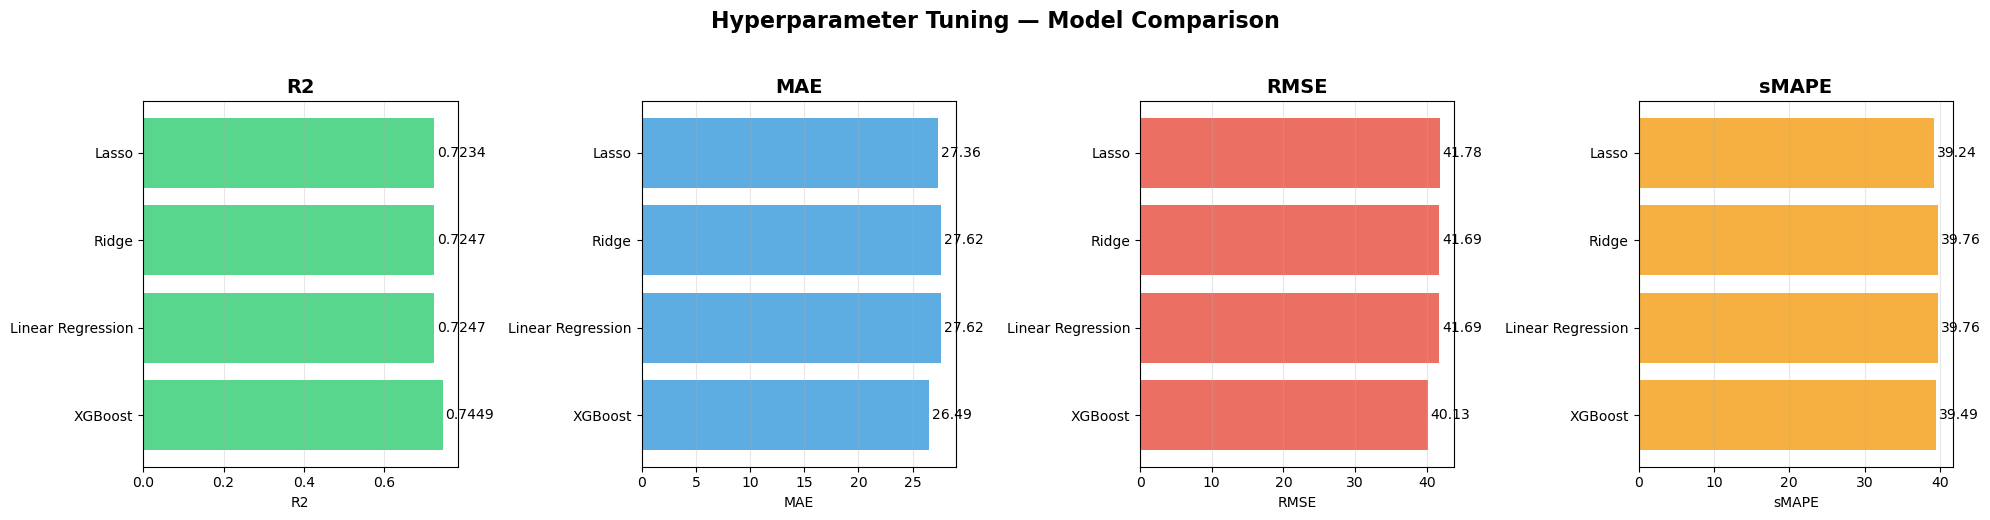

In [13]:
# =============================================================================
# VISUALIZATION: Compare model performance
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics_to_plot = ['R2', 'MAE', 'RMSE', 'sMAPE']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    models = df_results['Model'].tolist()
    values = df_results[metric].tolist()
    
    bars = ax.barh(models, values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xlabel(metric)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.01 * max(values), bar.get_y() + bar.get_height()/2, 
                f'{val}', va='center', fontsize=10)

plt.suptitle('Hyperparameter Tuning — Model Comparison', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## Save Best Model Profiles

In [14]:
# =============================================================================
# SAVE BEST MODEL PROFILES
# =============================================================================

profiles = {}

for name, search_obj, metrics in model_info:
    profiles[name] = {
        'best_rmse': metrics['RMSE'],
        'best_params': search_obj.best_params_
    }

# Save to JSON
with open(RESULTS_PATH, 'w') as f:
    json.dump(profiles, f, indent=4, default=str)

print(f'Model profiles saved to: {RESULTS_PATH}')
print(json.dumps(profiles, indent=4, default=str))

Model profiles saved to: ../models_profiles.json
{
    "Linear Regression": {
        "best_rmse": 41.69,
        "best_params": {
            "fit_intercept": true
        }
    },
    "Ridge": {
        "best_rmse": 41.69,
        "best_params": {
            "alpha": 100.0,
            "fit_intercept": true
        }
    },
    "Lasso": {
        "best_rmse": 41.78,
        "best_params": {
            "alpha": 1.0,
            "fit_intercept": true,
            "max_iter": 1000
        }
    },
    "XGBoost": {
        "best_rmse": 40.13,
        "best_params": {
            "subsample": 0.9,
            "reg_lambda": 0.5,
            "reg_alpha": 0.01,
            "n_estimators": 100,
            "max_depth": 3,
            "learning_rate": 0.05,
            "colsample_bytree": 0.8
        }
    }
}
